In [1]:
from model import Kronos, KronosTokenizer, KronosPredictor

# Load from Hugging Face Hub
tokenizer = KronosTokenizer.from_pretrained("NeoQuasar/Kronos-Tokenizer-base")
model = Kronos.from_pretrained("NeoQuasar/Kronos-small")
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import sys
sys.path.append("../")


C:\Users\harsmith\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Initialize the predictor
predictor = KronosPredictor(model, tokenizer, max_context=512)

In [3]:
import pandas as pd

# Load your data
df = pd.read_csv(r"C:\Users\harsmith\Documents\GitHub\Kronos\tests\data\Download Data - STOCK_US_XNAS_SOFI.csv")
lookback = 400
pred_len = 120



In [9]:
def plot_prediction(kline_df, pred_df):
    pred_df.index = kline_df.index[-pred_df.shape[0]:]
    sr_close = kline_df['close']
    sr_pred_close = pred_df['close']
    sr_close.name = 'Ground Truth'
    sr_pred_close.name = "Prediction"

    sr_volume = kline_df['volume']
    sr_pred_volume = pred_df['volume']
    sr_volume.name = 'Ground Truth'
    sr_pred_volume.name = "Prediction"

    close_df = pd.concat([sr_close, sr_pred_close], axis=1)
    volume_df = pd.concat([sr_volume, sr_pred_volume], axis=1)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    ax1.plot(close_df['Ground Truth'], label='Ground Truth', color='blue', linewidth=1.5)
    ax1.plot(close_df['Prediction'], label='Prediction', color='red', linewidth=1.5)
    ax1.set_ylabel('Close Price', fontsize=14)
    ax1.legend(loc='lower left', fontsize=12)
    ax1.grid(True)

    ax2.plot(volume_df['Ground Truth'], label='Ground Truth', color='blue', linewidth=1.5)
    ax2.plot(volume_df['Prediction'], label='Prediction', color='red', linewidth=1.5)
    ax2.set_ylabel('Volume', fontsize=14)
    ax2.legend(loc='upper left', fontsize=12)
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig('forecast.png', dpi=150, bbox_inches='tight')
    plt.close(fig)

    from IPython.display import Image, display
    display(Image('forecast.png'))

In [5]:
import pandas as pd                                                                
                                                                                     
# Reload fresh to avoid stale state                                                
df = pd.read_csv(r"C:\Users\harsmith\Documents\GitHub\Kronos\tests\data\Download Data - STOCK_US_XNAS_SOFI.csv")                                                    
                                                        
# Clean column names and types in one pass (no inplace, no chained assignment)
df = df.rename(columns={
    'Date': 'date', 'Open': 'open', 'High': 'high',
    'Low': 'low', 'Close': 'close', 'Volume': 'volume'
})
df['timestamps'] = pd.to_datetime(df['date'], format='%m/%d/%Y')
df['volume'] = df['volume'].str.replace(',', '').astype(int)
df['open']  = df['open'].astype(float)
df['high']  = df['high'].astype(float)
df['low']   = df['low'].astype(float)
df['close'] = df['close'].astype(float)

# Sort chronologically (CSV is newest-first)
df = df.sort_values('timestamps').reset_index(drop=True)

pred_len = 5  # number of future trading days to forecast

x_df = df[['open', 'high', 'low', 'close', 'volume']].copy()
x_timestamp = df['timestamps']                           # datetime64 Series

# y_timestamp = future dates to predict (wrapped in Series so .dt works)
last_date = x_timestamp.iloc[-1]
y_timestamp = pd.Series(pd.bdate_range(start=last_date, periods=pred_len + 1)[1:])




print(f"x_timestamp dtype : {x_timestamp.dtype}")
print(f"y_timestamp dtype : {y_timestamp.dtype}")
print(f"Context rows      : {len(x_df)}")
print(f"Predicting {pred_len} days: {y_timestamp.iloc[0].date()} {y_timestamp.iloc[-1].date()}")
df.tail(3)



x_timestamp dtype : datetime64[ns]
y_timestamp dtype : datetime64[ns]
Context rows      : 22
Predicting 5 days: 2026-05-29 2026-06-04


C:\Users\harsmith\AppData\Local\Temp\ipykernel_5788\2878364112.py:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['timestamps'] = pd.to_datetime(df['date'], format='%m/%d/%Y')
C:\Users\harsmith\AppData\Local\Temp\ipykernel_5788\28783641

,date,open,high,low,close,volume,timestamps
19,05/26/2026,16.48,16.95,15.86,15.98,80583422,2026-05-26
20,05/27/2026,16.05,16.69,16.01,16.17,66232352,2026-05-27
21,05/28/2026,16.02,17.08,15.82,16.97,69767891,2026-05-28


In [6]:
# Generate predictions
pred_df = predictor.predict(
    df=x_df,
    x_timestamp=x_timestamp,
    y_timestamp=y_timestamp,
    pred_len=pred_len,
    T=1.0,          # Temperature for sampling
    top_p=0.9,      # Nucleus sampling probability
    sample_count=1  # Number of forecast paths to generate and average
)

print("Forecasted Data Head:")
print(pred_df.head())

c:\Users\harsmith\Documents\GitHub\Kronos\model\kronos.py:540: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[self.amt_vol] = df[self.vol_col] * df[self.price_cols].mean(axis=1)
100%|██████████| 5/5 [00:00<00:00, 46.50it/s]

Forecasted Data Head:
                 open       high        low      close      volume  \
2026-05-29  16.909092  17.366091  16.686249  16.962694  64236488.0   
2026-06-01  16.718128  17.046124  16.432737  16.878557  64683456.0   
2026-06-02  16.656361  17.048172  16.415304  16.753811  74465408.0   
2026-06-03  16.711384  17.065649  16.559038  16.766121  57031712.0   
2026-06-04  16.969116  17.183804  16.560913  16.646784  53764880.0   

                  amount  
2026-05-29  1.090481e+09  
2026-06-01  1.050629e+09  
2026-06-02  1.229252e+09  
2026-06-03  9.322847e+08  
2026-06-04  8.872545e+08  


Forecasted Data Head:
         open       high        low      close      volume        amount
17  16.909092  17.366091  16.686249  16.962694  64236488.0  1.090481e+09
18  16.718128  17.046124  16.432737  16.878557  64683456.0  1.050629e+09
19  16.656361  17.048172  16.415304  16.753811  74465408.0  1.229252e+09
20  16.711384  17.065649  16.559038  16.766121  57031712.0  9.322847e+08
21  16.969116  17.183804  16.560913  16.646784  53764880.0  8.872545e+08


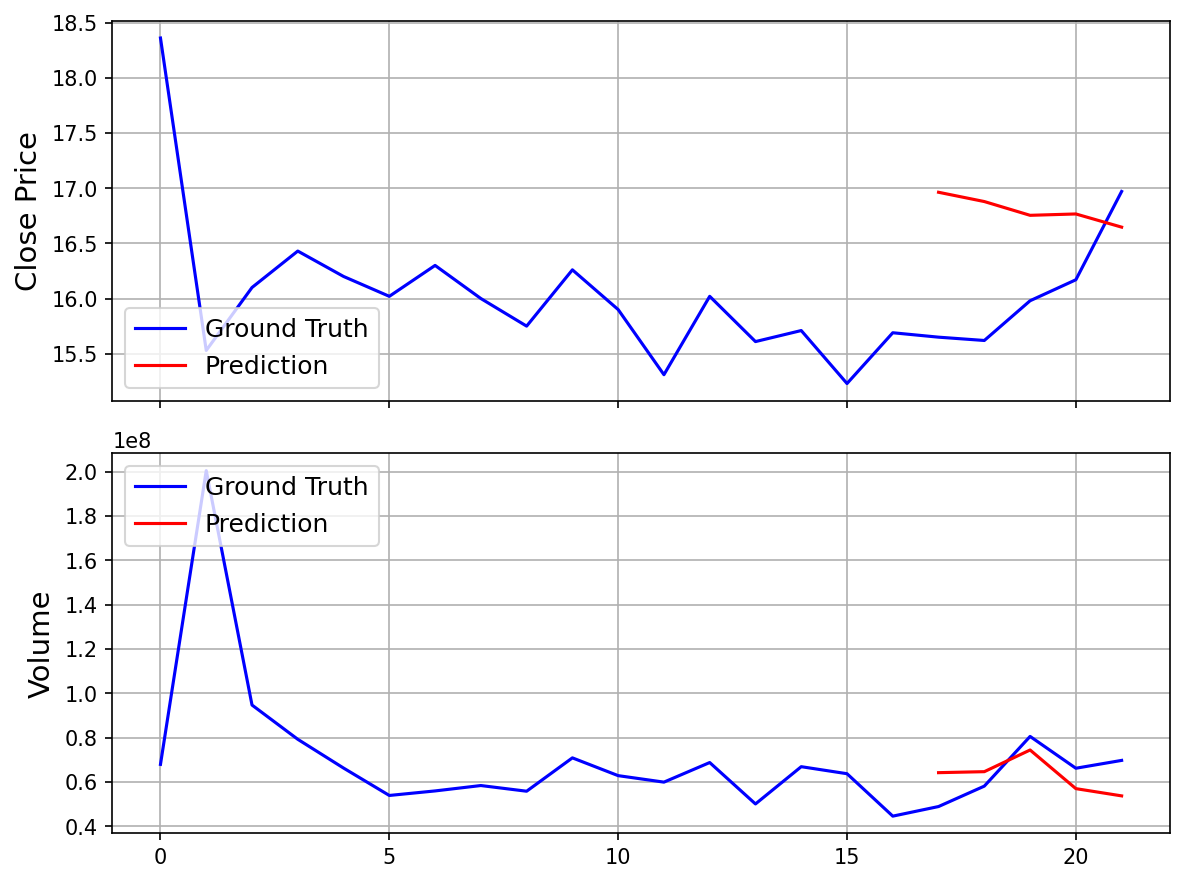

In [10]:
print("Forecasted Data Head:")
print(pred_df.head())


# Combine historical and forecasted data for plotting
kline_df = df.loc[:lookback+pred_len-1]

# visualize
plot_prediction(kline_df, pred_df)
